# Apply methodology to time-series from HARPS-N

In [16]:
from astropy.io import fits
from astropy.time import Time
from astropy.timeseries import LombScargle

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime, timedelta
import pickle
from collections import Counter

import scipy.stats as ss
from sklearn.decomposition import PCA

import re  # find pattern in string
from tqdm import tqdm  # progress bar

import tools as t

In [17]:
# define the path of the directory where data is saved
path_data = '../data/dace_sun/short_series/'

# sub directories of path_data
direc_stack = 'STACKED/'  # contains stacked files (.p), returned by rassine
direc_pre = 'PREPROCESSED/'  # contains preprocessed files (.p), returned by rassine
direc_raw = 'RAW/'  # contains raw files (.fits), downloaded from DACE and used to run rassine

# load absorption bands, to show in plots
bands = np.genfromtxt('../data/bands.txt', dtype=None, encoding=None, names=True, delimiter=',')

In [18]:
# save names of files

rassine_files = []  # only files in direc_stack that start by "RASSINE"
stacked_files = []  # all the other files in direc_stack
for entry in os.scandir(path_data + direc_stack):
    name = entry.name
    if name.endswith('.p'):
        if name.startswith('RASSINE'):
            rassine_files.append(name)
        else:
            stacked_files.append(name)

pre_files = []  # all files in direc_pre
for entry in os.scandir(path_data + direc_pre):
    pre_files.append(entry.name)

raw_files = []  # all files in direc_raw
for entry in os.scandir(path_data + direc_raw):
    raw_files.append(entry.name)

print(rassine_files)

['RASSINE_Stacked_spectrum_B1.00_D2015-08-02T10:33:41.605.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-07-29T22:35:17.577.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-08-03T13:39:03.510.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-07-30T16:44:40.511.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-07-29T10:29:33.313.p', 'RASSINE_Stacked_spectrum_B1.00_D2015-08-02T22:18:14.625.p']


In [19]:
path_ex1 = path_data + direc_stack + rassine_files[0]
data_ex1 = pickle.load(open(path_ex1, "rb"))
print(data_ex1.keys())

path_ex2 = path_data + direc_stack + stacked_files[0]
data_ex2 = pickle.load(open(path_ex2, "rb"))
print(data_ex2.keys())

dict_keys(['wave', 'flux', 'flux_err', 'flux_used', 'output', 'parameters', 'matching_anchors', 'matching_diff'])
dict_keys(['flux', 'flux_err', 'jdb', 'mjd', 'berv', 'lamp_offset', 'acc_sec', 'RV_shift', 'RV_sys', 'SNR_5500', 'hole_left', 'hole_right', 'wave_min', 'wave_max', 'dwave', 'stacking_length', 'nb_spectra_stacked', 'arcfiles'])


In [20]:
# show keys of each type of file
path_ras = path_data + direc_stack + rassine_files[0]
data_ras = pickle.load(open(path_ras, "rb"))
print('---------- KEYS OF RASSINE STACKED FILES ----------')
print(data_ras.keys())

print('\n---------- KEYS OF STACKED FILES ----------')
path_stack = path_data + direc_stack + stacked_files[0]
data_stack = pickle.load(open(path_stack, "rb"))
print(data_stack.keys())
print(f'Number of spectra stacked in {stacked_files[0]}: {len(data_stack['arcfiles'])}')

print('\n---------- KEYS OF STACKED FILES ----------')
path_pre = path_data + direc_pre + pre_files[0]
data_pre = pickle.load(open(path_pre, "rb"))
print(data_pre.keys())

print('\n---------- COLUMNS OF RAW FILES ----------')
path_raw = path_data + direc_raw + raw_files[0]
data_raw = fits.getdata(path_raw, 1)
print(data_raw.columns)

---------- KEYS OF RASSINE STACKED FILES ----------
dict_keys(['wave', 'flux', 'flux_err', 'flux_used', 'output', 'parameters', 'matching_anchors', 'matching_diff'])

---------- KEYS OF STACKED FILES ----------
dict_keys(['flux', 'flux_err', 'jdb', 'mjd', 'berv', 'lamp_offset', 'acc_sec', 'RV_shift', 'RV_sys', 'SNR_5500', 'hole_left', 'hole_right', 'wave_min', 'wave_max', 'dwave', 'stacking_length', 'nb_spectra_stacked', 'arcfiles'])
Number of spectra stacked in Stacked_spectrum_B1.00_D2015-08-02T10:33:41.605.p: 32

---------- KEYS OF STACKED FILES ----------
dict_keys(['flux', 'flux_err', 'RV_sys', 'RV_shift', 'SNR_5500', 'berv', 'lamp_offset', 'plx_mas', 'acc_sec', 'instrument', 'mjd', 'jdb', 'hole_left', 'hole_right', 'wave_min', 'wave_max', 'dwave'])

---------- COLUMNS OF RAW FILES ----------
ColDefs(
    name = 'wavelength'; format = '1D'; unit = 'angstrom'
    name = 'wavelength_air'; format = '1D'; unit = 'angstrom'
    name = 'flux'; format = '1D'; unit = 'e-'
    name = 'erro

In [21]:
# show SNR of raw HARPS-N spectra

snr550_list = []  # SNR at 550 nm of each raw file
snr_list = []  # [median, mean, std] SNR of each raw file

for spec in raw_files:
    path_spec = path_data + direc_raw + spec
    data_spec = fits.getdata(path_spec, 1)
    wl = data_spec['wavelength']
    snr = data_spec['flux'] / data_spec['error']  # SNR = flux / flux_error
    snr = snr[np.isfinite(snr)]  # take out cases where SNR = infinity
    snr550 = snr[np.where(np.round(wl, 2) == 5500.00)[0][0]]  # get value at 550 nm
    snr550_list.append(snr550)
    snr_list.append([np.median(snr), np.mean(snr), np.std(snr)])

snr550_list = np.array(snr550_list)
snr_list = np.array(snr_list)

/tmp/ipykernel_144000/3090225321.py:10: RuntimeWarning: invalid value encountered in divide
  snr = data_spec['flux'] / data_spec['error']  # SNR = flux / flux_error


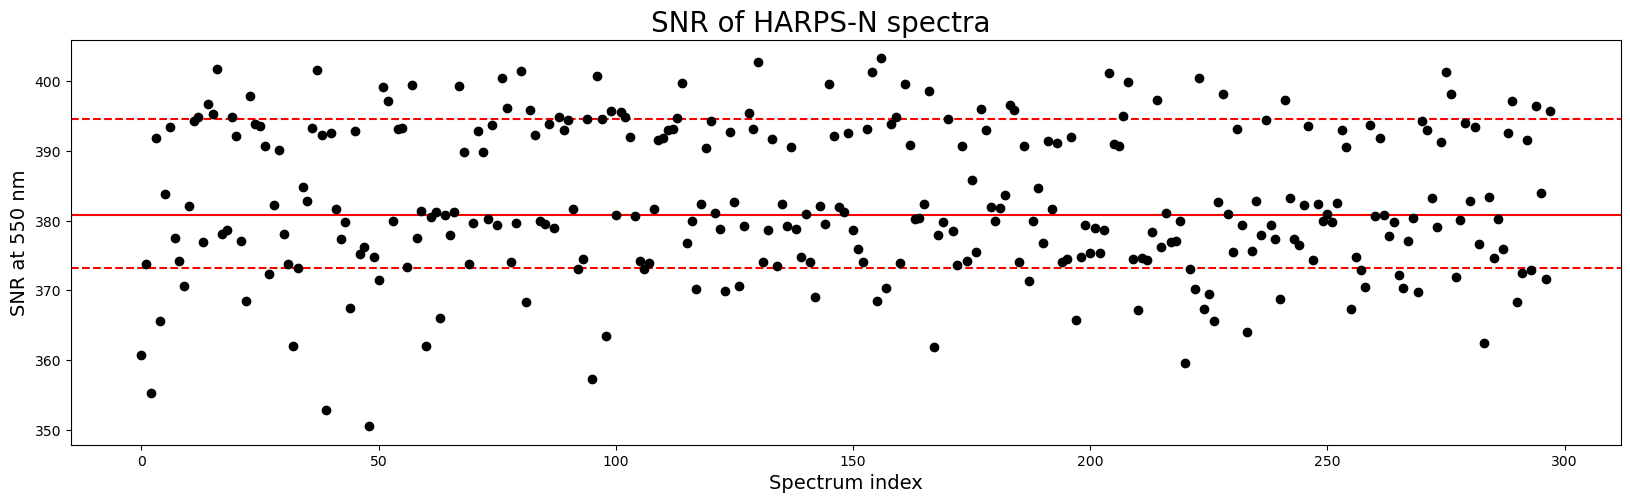

In [22]:
# show SNR at 550 nm
x = np.arange(0, len(raw_files), 1)

fig, ax = plt.subplots(figsize=(20, 5))
fig.suptitle('SNR of HARPS-N spectra', size=20)

ax.scatter(x, snr550_list, color='k')
ax.axhline(np.median(snr550_list), color='red', zorder=-1)
ax.axhline(np.percentile(snr550_list, 16), color='red', zorder=-1, linestyle='--')
ax.axhline(np.percentile(snr550_list, 84), color='red', zorder=-1, linestyle='--')
ax.set_xlabel('Spectrum index', size=14)
ax.set_ylabel('SNR at 550 nm', size=14)

plt.subplots_adjust(top=.92)
plt.show()

In [23]:
# median, p16 and p84 SNR at 550 nm
print(f'Median = {np.median(snr550_list)}')
print(f'p16 = {np.percentile(snr550_list, 16)}')
print(f'p84 = {np.percentile(snr550_list, 84)}')

Median = 380.79833878099134
p16 = 373.18263051305127
p84 = 394.5611506958261


In [24]:
# save important data: data from rassine files + arcfiles from stacked files
data = {}
for stacked_name in stacked_files:  # iterate over stacked files
    for ras_name in rassine_files:  # iterate over rassine files
        if ras_name.endswith(stacked_name):  # names of the files coincide
            data_ras = pickle.load(open(path_data + direc_stack + ras_name, "rb"))  # load rassine stacked data
            data_stack = pickle.load(open(path_data + direc_stack + stacked_name, "rb"))  # load stacked data
            data_ras['arcfiles'] = data_stack['arcfiles']  # add number of stacked files from stack to ras
            data[stacked_name] = data_ras  # save data
            break

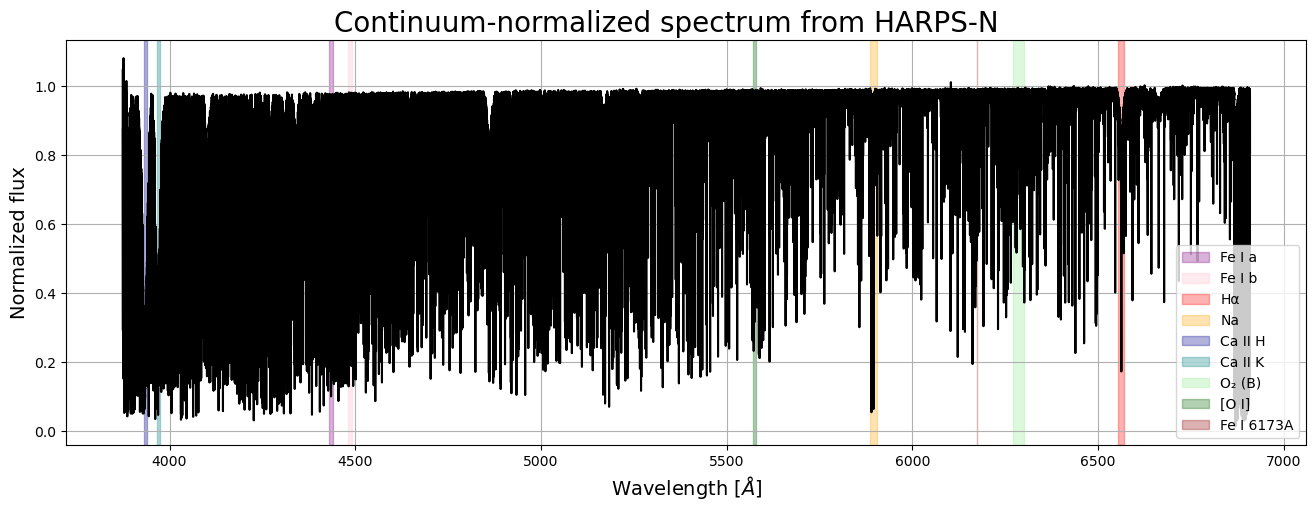

In [26]:
# example of normalized spectrum

ex = list(data.keys())[0]  # example file

# data from example file
wl = data[ex]['wave']
cont = data[ex]['output']['continuum_linear']
pre_files = data[ex]['arcfiles']
n_files = len(pre_files)
stacked_flux = data[ex]['flux']
flux = []

# get preprocessing data of the files that were stacked
for f in pre_files:
    data_f = pickle.load(open(f, "rb"))
    flux.append(data_f['flux'])


# plot
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Continuum-normalized spectrum from HARPS-N', size=20)

ax.grid()
ax.plot(wl, flux[10] * n_files / cont, 'k')  # flux[10] as an example, multiply by number of files because the continuum is stacked
for j in bands:
        ax.axvspan(xmin=j['start']*10, xmax=j['end']*10, color=j['color'], label=j['name'], alpha=.3)
ax.set_xlabel(r'Wavelength [$\AA$]', size=14)
ax.set_ylabel('Normalized flux', size=14)
ax.legend()

plt.subplots_adjust(top=.92)
plt.show()

In [27]:
# data for each file
files_data = {}  # data dictionary: {file_path: {wl, flux, flux_err, flux_norm, flux_norm_err, time}}
pattern = re.compile(r"\d{4}-\d{2}-\d{2}T\d{2}_\d{2}_\d{2}\.\d+")  # pattern to look for in the files names, in order to get datetime
for stacked_name in data.keys():  # iterate over names of stacked files
    
    wl = data[stacked_name]['wave']  # save wl array
    cont = data[stacked_name]['output']['continuum_linear']  # save continuum (same for all files in 'arcfiles')
    pre_files = data[stacked_name]['arcfiles']  # names of files used in the stacking by RASSINE
    n_files = len(pre_files)  # number of stacked spectra
    #stacked_flux = data[stacked_name]['flux']  # save stacked flux (not used)

    for f in pre_files:  # iterate over preprocessing files used in the stacked file
        
        data_f = pickle.load(open(f, "rb"))
        flux = data_f['flux']  # save flux
        err = data_f['flux_err']  # save error
        time_str = t.extract_pattern(f, pattern)  # get datetime from the file's name
         # save important data from each of the preprocessing files
        files_data[f] = {'wl': wl,
                         'flux': flux,
                         'flux_err': err,
                         'flux_norm': flux * n_files / cont,
                         'flux_norm_err': err * n_files / cont,
                         'time': datetime.strptime(time_str, "%Y-%m-%dT%H_%M_%S.%f")}

In [28]:
# recover RV data from the master table
data_rv = pd.read_csv(path_data + 'DACE_TABLE/Dace_extracted_table.csv')
rv_files = data_rv['fileroot'].to_numpy()
for name in files_data.keys():  # iterate over files names
    time_str = t.extract_pattern(name, pattern)  # get datetime from the file's name
    for rv_name in rv_files:  # iterate over rv files names
        if time_str in rv_name:  # use time to find the corresponding rv file
            rv = float(data_rv[data_rv['fileroot'] == rv_name]['vrad'].item()) * 1000  # recover rv in km/s, multiplied by 1000 to get m/s
            files_data[name]['rv'] = rv  # add rv to the corresponding file files_data
            break

In [29]:
# time array
times = [i['time'] for i in files_data.values()]
print(times)

[datetime.datetime(2015, 8, 2, 9, 4, 2, 296000), datetime.datetime(2015, 8, 2, 9, 9, 29, 141000), datetime.datetime(2015, 8, 2, 9, 14, 54, 449000), datetime.datetime(2015, 8, 2, 9, 20, 20, 141000), datetime.datetime(2015, 8, 2, 9, 25, 44, 682000), datetime.datetime(2015, 8, 2, 9, 31, 8, 839000), datetime.datetime(2015, 8, 2, 9, 36, 34, 534000), datetime.datetime(2015, 8, 2, 9, 47, 26, 703000), datetime.datetime(2015, 8, 2, 9, 52, 50, 475000), datetime.datetime(2015, 8, 2, 9, 58, 14, 664000), datetime.datetime(2015, 8, 2, 10, 3, 40, 741000), datetime.datetime(2015, 8, 2, 10, 9, 4, 513000), datetime.datetime(2015, 8, 2, 10, 14, 28, 670000), datetime.datetime(2015, 8, 2, 10, 19, 53, 210000), datetime.datetime(2015, 8, 2, 10, 25, 18, 519000), datetime.datetime(2015, 8, 2, 10, 30, 42, 292000), datetime.datetime(2015, 8, 2, 10, 36, 6, 832000), datetime.datetime(2015, 8, 2, 10, 41, 31, 373000), datetime.datetime(2015, 8, 2, 10, 46, 55, 145000), datetime.datetime(2015, 8, 2, 10, 52, 19, 302000

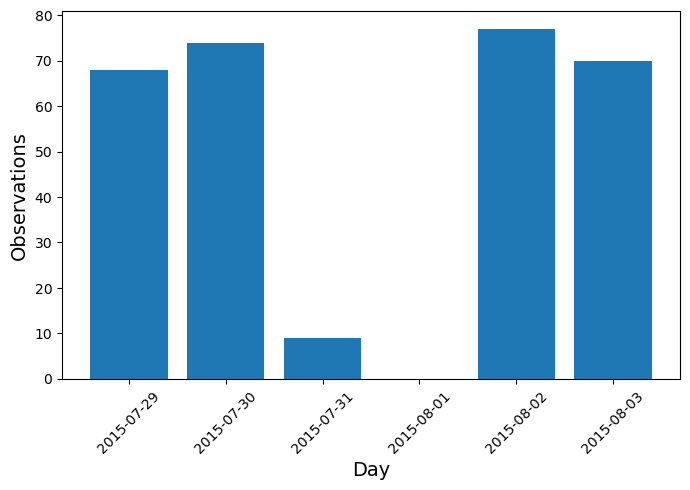

In [30]:
# show files per day
# group by day
counts = Counter(dt.date() for dt in times)

# plot histogram
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(counts.keys(), counts.values())
ax.set_xlabel('Day', size=14)
ax.set_ylabel('Observations', size=14)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [31]:
# make n-day groups
n_days = 3
times = []
for f, d in files_data.items():
    times.append(d['time'])
times = sorted(times)  # sort in ascending order

d_range = [min(times).date(), min(times).date() + timedelta(days=n_days)]  # define day range
dates_grouped = []
ind = 0  # group number
for dt in times:  # iterate over times
    if d_range[0] <= dt.date() < d_range[1]:
        if len(dates_grouped) == 0:  # if dt is the first element of times
            dates_grouped.append([dt])  # create a group, with dt as the first element
        else:
            dates_grouped[ind].append(dt)  # add to an existing group
    else:  # dt is out of the range
        d_range = [dt.date(), dt.date() + timedelta(days=n_days)]  # dt defines the new range, as the times list is sorted
        ind += 1  # new group, new index
        dates_grouped.append([dt])  # create a group, with dt as the first element

print(dates_grouped)

[[datetime.datetime(2015, 7, 29, 9, 1, 42, 883000), datetime.datetime(2015, 7, 29, 9, 7, 7, 38000), datetime.datetime(2015, 7, 29, 9, 12, 32, 347000), datetime.datetime(2015, 7, 29, 9, 17, 56, 902000), datetime.datetime(2015, 7, 29, 9, 23, 22, 210000), datetime.datetime(2015, 7, 29, 9, 28, 46, 751000), datetime.datetime(2015, 7, 29, 9, 34, 12, 444000), datetime.datetime(2015, 7, 29, 9, 39, 36, 985000), datetime.datetime(2015, 7, 29, 9, 45, 2, 327000), datetime.datetime(2015, 7, 29, 9, 50, 26, 482000), datetime.datetime(2015, 7, 29, 9, 55, 51, 20000), datetime.datetime(2015, 7, 29, 10, 1, 16, 328000), datetime.datetime(2015, 7, 29, 10, 6, 41, 252000), datetime.datetime(2015, 7, 29, 10, 12, 6, 175000), datetime.datetime(2015, 7, 29, 10, 17, 30, 715000), datetime.datetime(2015, 7, 29, 10, 22, 54, 870000), datetime.datetime(2015, 7, 29, 10, 28, 20, 176000), datetime.datetime(2015, 7, 29, 10, 33, 45, 100000), datetime.datetime(2015, 7, 29, 10, 39, 10, 408000), datetime.datetime(2015, 7, 29,

In [32]:
data_grouped = {}  # {group: {file: {data} } } 

for f, d in files_data.items():  # iterate over files and data in files_data
    dt = d['time']  # save time
    ind = next(i for i, sublist in enumerate(dates_grouped) if dt in sublist)  # get group index
    if ind not in data_grouped.keys():  # if group index not yet in data_grouped
        data_grouped[ind] = {}  # create sub-dict
    data_grouped[ind][f] = d  # save data

In [33]:
# show start and end of groups
for k in data_grouped.keys():
    t1 = [data_grouped[k][i]['time'] for i in data_grouped[k]]
    print(f'Group {k} starts {min(t1)} and ends {max(t1)}.')

Group 1 starts 2015-08-02 09:04:02.296000 and ends 2015-08-03 15:16:55.692000.
Group 0 starts 2015-07-29 09:01:42.883000 and ends 2015-07-31 08:56:17.408000.


In [34]:
# save arrays of data in their respective groups
groups = {}  # {group: {wl, flux, flux_err, flux_norm, flux_norm_err, time, rv} }
for i, d in data_grouped.items():
    wl = []
    flux = []
    flux_err = []
    flux_norm = []
    flux_norm_err = []
    obs_time = []
    rv = []
    for f, dd in d.items():
        if len(wl) == 0:
            wl = dd['wl']  # same wl for every file (verified)
        flux.append(dd['flux'])
        flux_err.append(dd['flux_err'])
        flux_norm.append(dd['flux_norm'])
        flux_norm_err.append(dd['flux_norm_err'])
        obs_time.append(dd['time'])
        rv.append(dd['rv'])
    groups[i] = {'wl': np.array(wl), 'flux': np.array(flux), 'flux_err': np.array(flux_err), 'flux_norm': np.array(flux_norm), 'flux_norm_err': np.array(flux_norm_err), 'time': np.array(obs_time), 'rv': np.array(rv)}

In [35]:
# apply PCA to each group
n_components = 20
pca = {}  # {group: {wl, time, time_jd, mean_spec, loadings, scores, var, periodograms} }
for i, d in groups.items():
    # get spectra matrix
    spectra = d['flux_norm']
    rv = d['rv']
    times = d['time']
    times_jd = Time(times).jd
    # prepare spectra for PCA
    mean_spec = np.mean(spectra, axis=0)  # calculate mean spectrum (i.e. the mean flux for each wl)
    S_f, D = t.subtract_D(wl, spectra, c=3e8)  # take out projection over the velocity vector
    spectra_centered = t.double_centering(S_f)  # apply double centering to the spectra matrix
    # apply PCA
    pca_flux = PCA(n_components=n_components)  # create PCA object
    pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
    var  = pca_flux.explained_variance_ratio_  # variance explained by each PC
    loadings = pca_flux.components_
    scores = np.array([pcs[:, i] for i in range(n_components)])
    periodograms = [LombScargle(times_jd, scores[i]).autopower() for i in range(n_components)]  # score periodograms
    r = np.array([ss.pearsonr(i, rv)[0] for i in scores])  # correlation coefficient between rv and PCs
    # save data
    pca[i] = {'wl': d['wl'], 'time': times, 'time_jd': times_jd, 'mean_spec': mean_spec, 'loadings': loadings, 'scores': scores, 'var': var, 'pgrams': periodograms, 'corr': r}

In [36]:
# component significance (cannot use function from tools because of shape issues with the paremeter sigma, which is an array in this case, while the function expects a float)
N_r = 20
maxes_grouped = {}  # {group: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]}
for i, d in groups.items():  # iterate over groups
    wl = d['wl']
    spectra = d['flux_norm']
    sigma = d['flux_norm_err']
    comps = pca[i]['loadings']
    simi_all = np.empty((N_r, n_components, n_components), dtype=np.float32)  # N_r squared matrices of n_components x n_components
    for j in tqdm(range(N_r)):  # iterate over realizations
        # preprocessing
        spectra_noisy = spectra + np.random.normal(0, sigma)  # add gaussian noise to the original data
        noise = np.random.normal(loc=0.0, scale=sigma)
        S_f_noisy, D = t.subtract_D(wl, spectra_noisy, c=3e8)  # take out projection over the velocity vector
        spectra_noisy = t.double_centering(S_f_noisy)
        # PCA
        pca_noisy = PCA(n_components=n_components)  # apply PCA to the noisy matrix
        pca_noisy.fit(spectra_noisy)

        comps_noisy = pca_noisy.components_  # save the loadings

        simi_all[j] = np.abs(comps @ comps_noisy.T)  # save dot product between original and noisy loadings
    maxes = np.array([np.amax(s, axis=1) for s in simi_all])  # max of each row of each realization
    stats = np.array([(np.average(s), np.std(s)) for s in maxes.T])  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]
    maxes_grouped[i] = stats

100%|██████████| 20/20 [02:30<00:00,  7.53s/it]


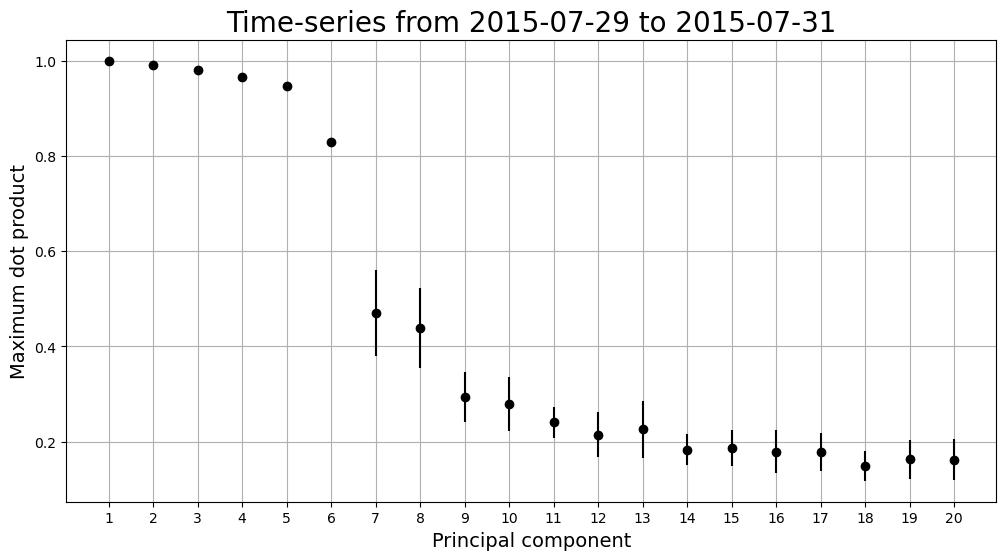

In [37]:
# plot component significance of the PCs of a group

group_ind = 0  # choose the group
x = np.arange(1, n_components + 1, 1)
times_group = pca[group_ind]['time']

fig, ax = plt.subplots(figsize=(12, 6))

ax.grid()
ax.errorbar(x, maxes_grouped[group_ind][:, 0], maxes_grouped[group_ind][:, 1], fmt='o', color='k', ecolor='k')
ax.set_title(f'Time-series from {min(times_group).date()} to {max(times_group).date()}', size=20)
ax.set_xlabel('Principal component', size=14)
ax.set_ylabel('Maximum dot product', size=14)
ax.set_xticks(x)

plt.show()

In [38]:
# get correlation coefficients

inds = list(groups.keys())
N_pcs = 20
r_ts = {}  # {group: [r(RV, PC1), ..., r(RV, PC_n)]}
for j in inds:  # iterate over groups
    r_j = []
    for i in range(N_pcs):
        r_j.append(pca[j]['corr'][i])
    r_ts[j] = r_j

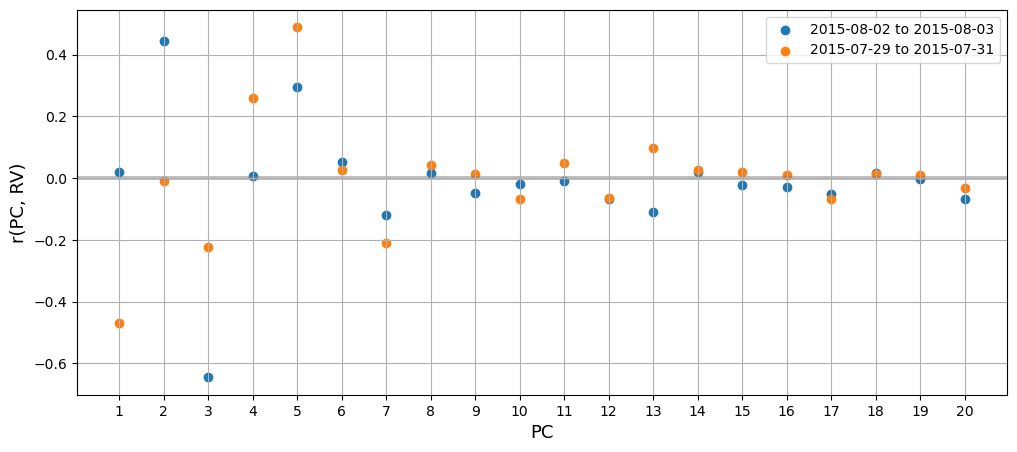

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(1, N_pcs + 1, 1)
avg_files = np.mean([len(i) for i in dates_grouped])  # average number of files per group

for i in inds:
    times_i = pca[i]['time']
    ax.scatter(x, r_ts[i], label=f'{min(times_i).date()} to {max(times_i).date()}')

ax.axhspan(-1/avg_files, 1/avg_files, facecolor='gray', alpha=0.5)
ax.grid()
ax.set_xticks(x)
ax.set_xlabel('PC', size=13)
ax.set_ylabel('r(PC, RV)', size=13)
ax.legend()

plt.show()

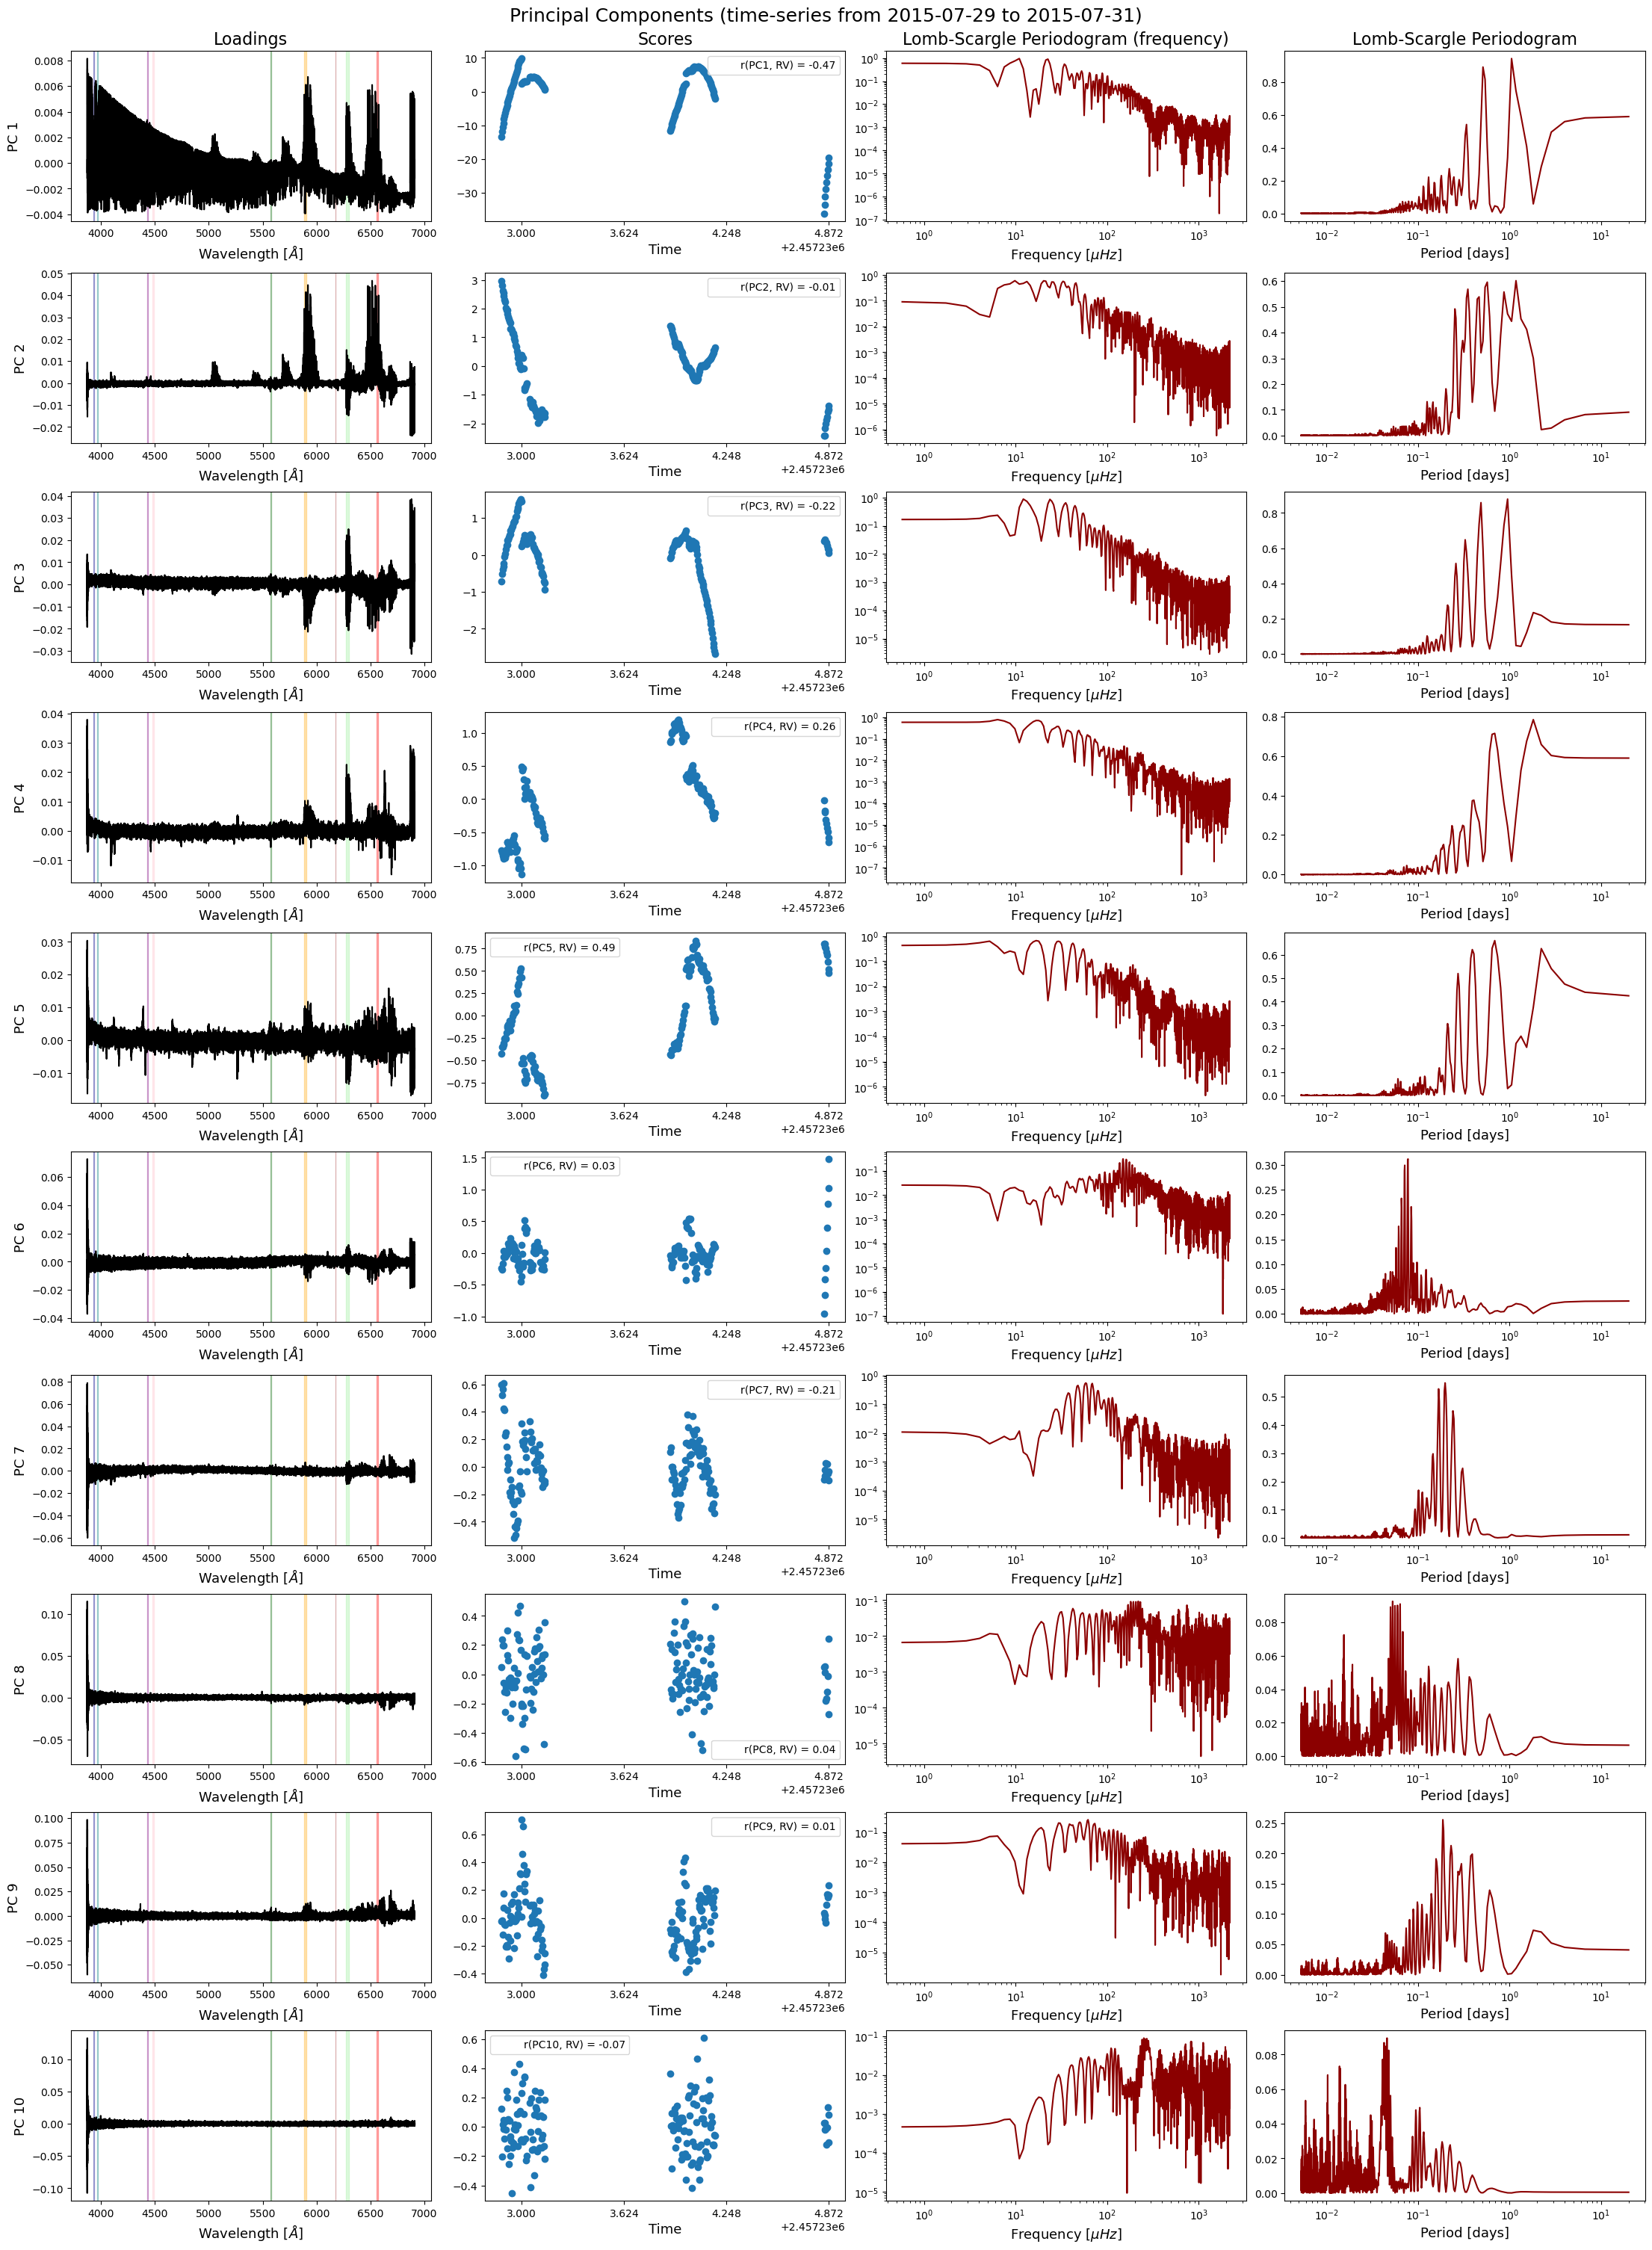

In [40]:
ind = 0  # group of days
wl = pca[ind]['wl']
times = pca[ind]['time']
times_jd = pca[ind]['time_jd']
loadings = pca[ind]['loadings']
scores = pca[ind]['scores']
corr = r_ts[0]
pgrams = pca[ind]['pgrams']
pc_numbers = np.arange(0, 10, 1)

t.plot_PCA(wl, loadings, times_jd, scores, corr, pgrams, pc_numbers, (min(times).date(), max(times).date()), bands)

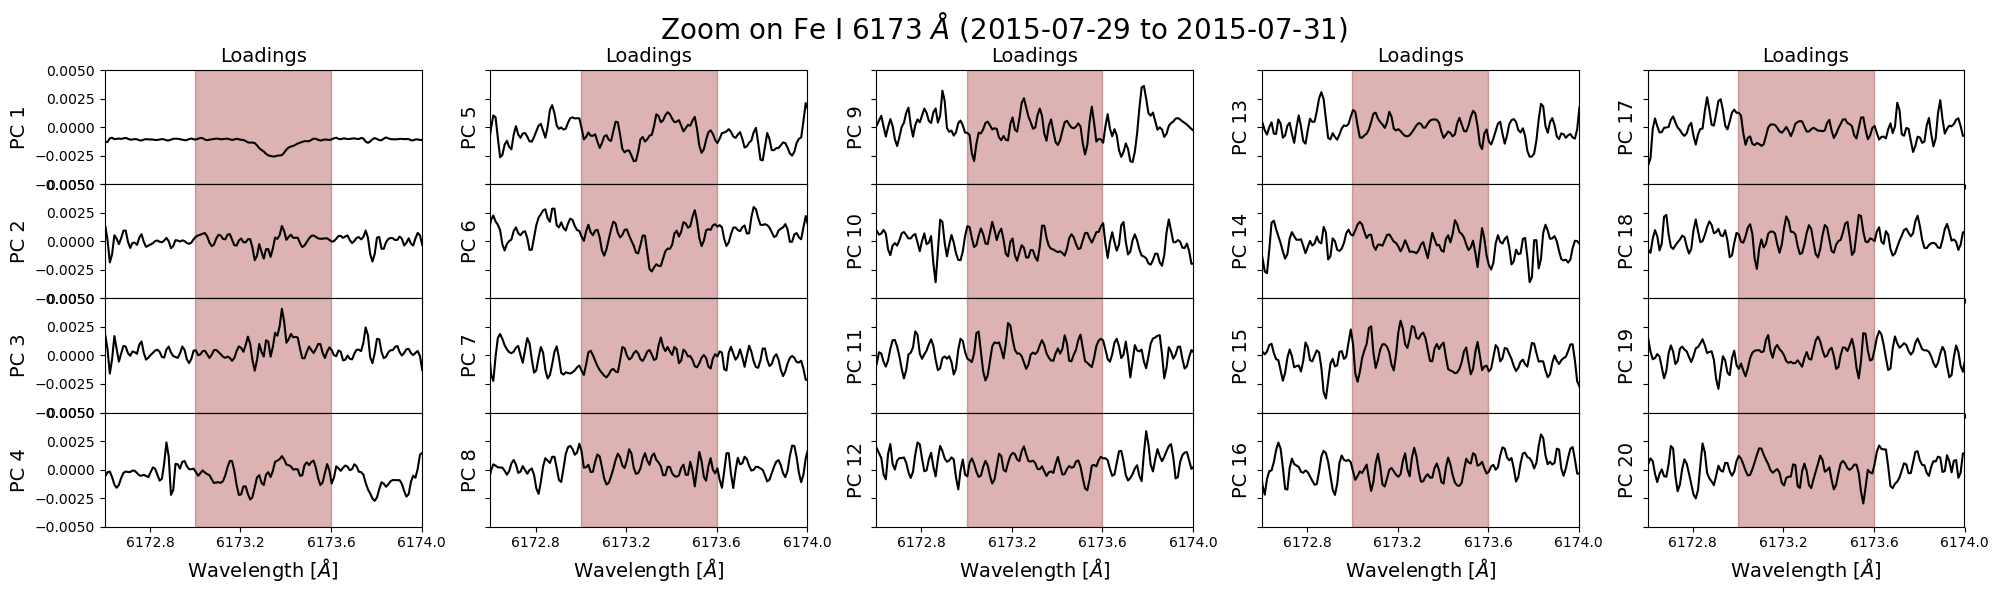

In [41]:
# zoom on the Fe I 6173 line
ind = 0  # choose group
rows = 4
cols = 5

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 1.5*rows), sharex=True, sharey=True)
fig.suptitle(r'Zoom on Fe I 6173 $\AA$' + f' ({min(times).date()} to {max(times).date()})', size=20)

row_i = 0
col_j = 0
pc_ind = 0
# Loadings
for j in range(cols):
    for i in range(rows):
        axs[i][j].plot(pca[ind]['wl'], pca[ind]['loadings'][pc_ind], color='k')
        for k in bands:
            axs[i][j].axvspan(xmin=k['start']*10, xmax=k['end']*10, color=k['color'], label=k['name'], alpha=.3)

        if i == 0:
            axs[i][j].set_title('Loadings', size=14)
        
        if i == rows - 1:
            axs[i][j].set_xlabel(r'Wavelength [$\AA$]', size=14)
        axs[i][j].set_ylabel(f'PC {pc_ind + 1}', size=14)
        axs[i][j].set_xlim(6172.6, 6174)
        axs[i][j].set_ylim(-0.005, 0.005)
        axs[i][j].xaxis.set_major_locator(ticker.MaxNLocator(4))  # limit number of xticks to improve readability

        pc_ind += 1

fig.tight_layout()
plt.subplots_adjust(top=.88, hspace=0)
plt.show()

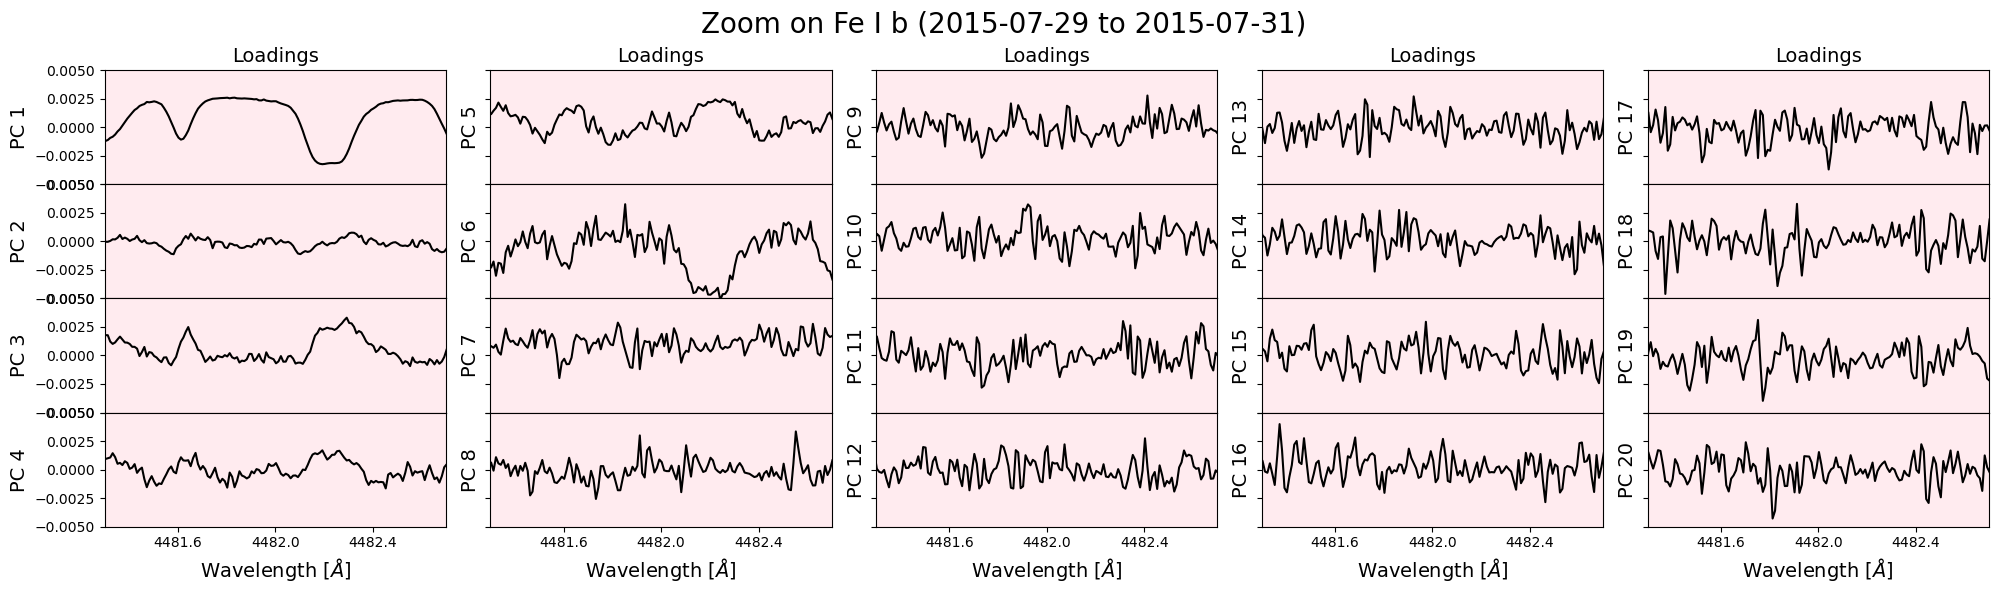

In [42]:
# zoom on the Fe I b line
rows = 4
cols = 5

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 1.5*rows), sharex=True, sharey=True)
fig.suptitle(f'Zoom on Fe I b ({min(times).date()} to {max(times).date()})', size=20)

row_i = 0
col_j = 0
pc_ind = 0
# Loadings
for j in range(cols):
    for i in range(rows):
        axs[i][j].plot(pca[ind]['wl'], pca[ind]['loadings'][pc_ind], color='k')
        for k in bands:
            axs[i][j].axvspan(xmin=k['start']*10, xmax=k['end']*10, color=k['color'], label=k['name'], alpha=.3)

        if i == 0:
            axs[i][j].set_title('Loadings', size=14)
        
        if i == rows - 1:
            axs[i][j].set_xlabel(r'Wavelength [$\AA$]', size=14)
        axs[i][j].set_ylabel(f'PC {pc_ind + 1}', size=14)
        axs[i][j].set_xlim(4481.3, 4482.7)
        axs[i][j].set_ylim(-0.005, 0.005)
        axs[i][j].xaxis.set_major_locator(ticker.MaxNLocator(4))

        pc_ind += 1

fig.tight_layout()
plt.subplots_adjust(top=.88, hspace=0)
plt.show()

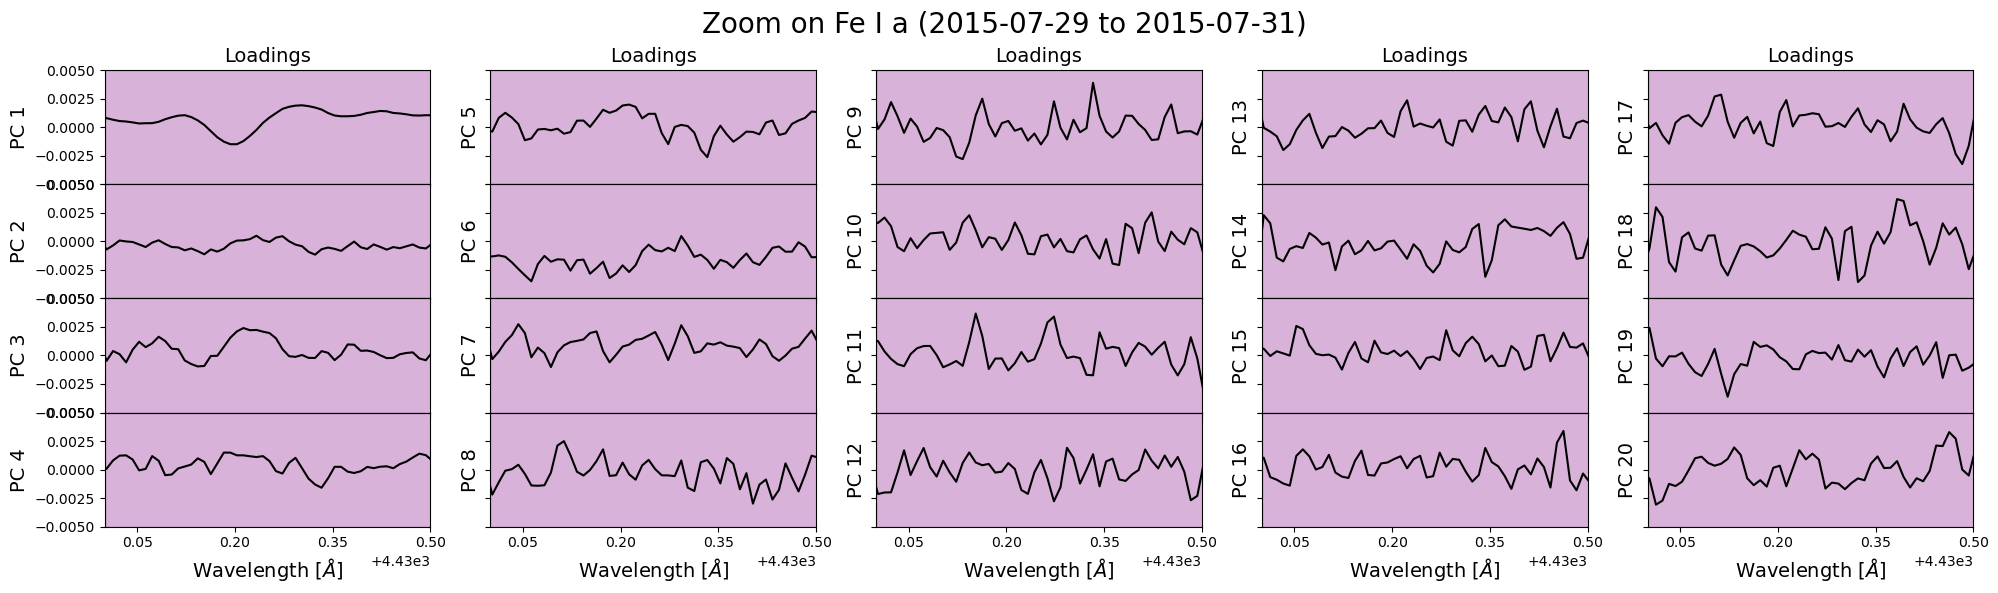

: 

In [ ]:
# zoom on the Fe I a line
rows = 4
cols = 5

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 1.5*rows), sharex=True, sharey=True)
fig.suptitle(f'Zoom on Fe I a ({min(times).date()} to {max(times).date()})', size=20)

row_i = 0
col_j = 0
pc_ind = 0
# Loadings
for j in range(cols):
    for i in range(rows):
        axs[i][j].plot(pca[ind]['wl'], pca[ind]['loadings'][pc_ind], color='k')
        for k in bands:
            axs[i][j].axvspan(xmin=k['start']*10, xmax=k['end']*10, color=k['color'], label=k['name'], alpha=.3)

        if i == 0:
            axs[i][j].set_title('Loadings', size=14)
        
        if i == rows - 1:
            axs[i][j].set_xlabel(r'Wavelength [$\AA$]', size=14)
        axs[i][j].set_ylabel(f'PC {pc_ind + 1}', size=14)
        axs[i][j].set_xlim(4430, 4430.5)
        axs[i][j].set_ylim(-0.005, 0.005)
        axs[i][j].xaxis.set_major_locator(ticker.MaxNLocator(4))

        pc_ind += 1

fig.tight_layout()
plt.subplots_adjust(top=.88, hspace=0)
plt.show()